In [69]:
# 데이터 불러오기

# pandas는 표 형태 데이터 처리, numpy는 수치 계산에 사용합니다.
import pandas as pd
import numpy as np

# 사용할 CSV 파일의 경로를 지정합니다.
path = '/content/drive/MyDrive/Colab Notebooks/abalone.csv'
# CSV 파일을 읽어 pandas DataFrame으로 만듭니다.
df = pd.read_csv(path)

In [70]:
# 데이터 출력해서 확인
# 데이터가 제대로 불러와졌는지 앞부분을 확인합니다.
df.head()

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [71]:
#label, feature 데이터 입력하

# 예측해야 할 정답(label 또는 target) 컬럼을 y에 저장합니다.
y=df['Rings']

# 문자열 범주형 변수는 원-핫 인코딩으로 숫자 컬럼으로 변환합니다.
Y = pd.get_dummies(y).values

# 모델 입력에 사용할 특징(feature) 데이터를 X에 저장합니다.
X = df.drop(['id', 'Rings'], axis=1)

#원-핫 인코딩, 숫자가 아닌 feature 있어서
# 문자열 범주형 변수는 원-핫 인코딩으로 숫자 컬럼으로 변환합니다.
X = pd.get_dummies(X, columns=['Sex'])

In [72]:
y.value_counts()

,count
Rings,
9,689
10,634
8,568
11,487
7,391
12,267
6,259
13,203
14,126


In [73]:


# 정규화 (데이터를 비슷한 범위로 맞추는 작업)
# StandardScaler는 각 특징의 평균을 0, 표준편차를 1에 가깝게 맞춥니다.
from sklearn.preprocessing import StandardScaler
# 정규화를 수행할 스케일러 객체를 만듭니다.
scaler = StandardScaler()
# 모델 입력에 사용할 특징(feature) 데이터를 X에 저장합니다.
X = scaler.fit_transform(X)

# numpy 변환 필요 없음, 이미 scaler.fit_transform(X) 에서 넘파이 변환 됨


In [74]:
# 데이터를 학습용과 테스트용으로 나누기 위한 함수를 불러옵니다.
from sklearn.model_selection import train_test_split

# 전체 데이터 중 75%는 학습, 25%는 테스트에 사용합니다.
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.25, random_state=0
)

In [75]:
# Keras의 layers와 models를 사용해 신경망을 구성합니다.
from tensorflow.keras import layers, models
# 층(layer)을 순서대로 쌓는 모델, 입력 → 은닉층 → 출력층으로 일직선 구조

# Sequential 모델은 입력층부터 출력층까지 층을 순서대로 쌓는 방식입니다.
model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)), # 첫 번째 층 (입력층 + 은닉층),
    # 뉴런(노드) 64개, 입력 데이터의 컬럼 개수, activation="relu" <- 활성화 함수
    layers.Dropout(0.3), # 30% 뉴런을 랜덤으로 off > 과적합 방지
    layers.Dense(32, activation="relu"),# 두 번째 은닉층, 뉴런을 64 → 32로 줄이면서 중요한 정보만 남김
    # 다중 분류 문제이므로 클래스 개수만큼 출력 뉴런을 두고 softmax로 확률을 만듭니다.
    layers.Dense(Y.shape[1], activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [76]:
# 컴파일
# compile 단계에서 최적화 방법, 손실 함수, 평가 지표를 정합니다.
model.compile(
    optimizer="adam", # 가중치 업데이트 방법, 자동으로 학습률 조정
    loss="categorical_crossentropy",
    metrics=["accuracy"] # 정확도 측정
)

In [77]:
# 모델학습
# fit 결과를 history에 저장해 학습 과정의 loss와 metric 변화를 나중에 확인합니다.
history = model.fit(
    X_train, y_train,
    validation_split=0.2, # 학습 데이터 중 20%를 검증용으로 사용
    epochs=50, # 전체 데이터를 50번 반복 학습
    batch_size=16, # 한 번에 16개씩 학습
    verbose=1 # 학습 과정 출력
)

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1745 - loss: 2.7786 - val_accuracy: 0.2089 - val_loss: 2.4096
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2291 - loss: 2.2887 - val_accuracy: 0.2392 - val_loss: 2.2357
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2399 - loss: 2.1832 - val_accuracy: 0.2536 - val_loss: 2.1514
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2487 - loss: 2.1287 - val_accuracy: 0.2584 - val_loss: 2.1154
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2567 - loss: 2.0874 - val_accuracy: 0.2648 - val_loss: 2.0778
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2539 - loss: 2.0625 - val_accuracy: 0.2727 - val_loss: 2.0553
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2495 - loss: 2.0579 - val_accuracy: 0.2823 - val_loss: 2.0346
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2703 - loss: 2.0267 - val_accuracy: 0.

In [78]:

# 테스트 데이터에 대한 예측값을 생성합니다.
y_pred = model.predict(X_test)
# one-hot/probability 형태를 실제 클래스 번호로 바꿔 평가할 수 있게 합니다.
y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [79]:
# 그래프 그리기용 데이터 저장
# history에서 학습 손실 값을 꺼내 그래프용 변수로 저장합니다.
loss = history.history['loss']
# 검증 손실은 학습하지 않은 검증 데이터에서의 오차입니다.
val_loss = history.history['val_loss']
# 학습 데이터 기준 정확도 변화를 저장합니다.
acc = history.history['accuracy']
# 검증 데이터 기준 정확도 변화를 저장합니다.
val_acc = history.history['val_accuracy']


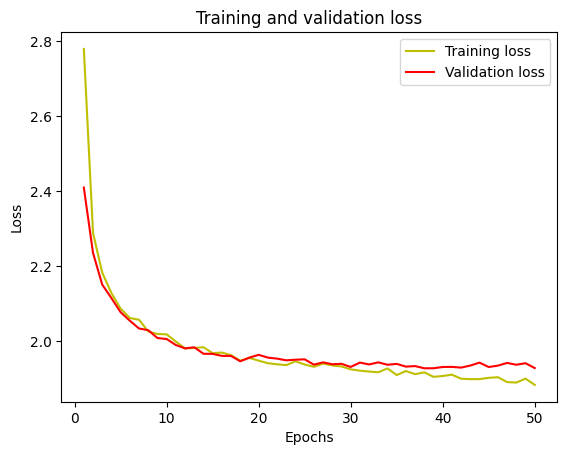

In [80]:
# 학습 과정에서 손실(loss)이 어떻게 변하는지 시각화

# matplotlib은 그래프를 그릴 때 사용합니다.
import matplotlib.pyplot as plt
# seaborn은 통계 그래프와 히트맵을 보기 좋게 그릴 때 사용합니다.
import seaborn as sns

# history에서 학습 손실 값을 꺼내 그래프용 변수로 저장합니다.
loss = history.history['loss'] # loss = 훈련 데이터 오차 /
# 검증 손실은 학습하지 않은 검증 데이터에서의 오차입니다.
val_loss = history.history['val_loss'] # val_loss = 검증 데이터 오차
# history는 model.fit() 결과
# epoch 번호를 x축으로 사용하기 위해 범위를 만듭니다.
epochs = range(1, len(loss) + 1) # x축 만들기

# 저장된 학습 기록을 선 그래프로 시각화합니다.
plt.plot(epochs, loss, 'y', label='Training loss') # 훈련 데이터 손실
# x축: epoch y축: loss 'y': 노란색
plt.plot(epochs, val_loss, 'r', label='Validation loss') # 검증 데이터 손실
# 'r': 빨간색
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


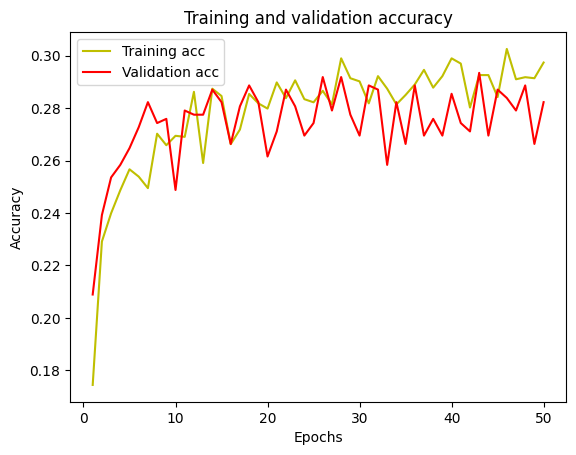

In [81]:
# 학습 데이터 기준 정확도 변화를 저장합니다.
acc = history.history['accuracy'] # 훈련 데이터 정확도
# 검증 데이터 기준 정확도 변화를 저장합니다.
val_acc = history.history['val_accuracy'] # 검증 데이터 정확도
# 저장된 학습 기록을 선 그래프로 시각화합니다.
plt.plot(epochs, acc, 'y', label='Training acc') # 훈련 정확도 (노란색)
plt.plot(epochs, val_acc, 'r', label='Validation acc') # 검증 정확도 (빨간색)
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [82]:

# classification_report와 confusion_matrix로 분류 성능을 자세히 확인합니다.
from sklearn.metrics import classification_report,confusion_matrix
# precision, recall, f1-score를 클래스별로 출력합니다.
print(classification_report(y_test_class,y_pred_class))
# 혼동 행렬은 실제 클래스와 예측 클래스의 대응 관계를 보여줍니다.
print(confusion_matrix(y_test_class,y_pred_class))

              precision    recall  f1-score   support

           2       0.00      0.00      0.00         7
           3       0.21      0.46      0.29        13
           4       0.23      0.07      0.11        40
           5       0.34      0.37      0.35        63
           6       0.41      0.44      0.42       114
           7       0.42      0.29      0.34       139
           8       0.29      0.47      0.36       152
           9       0.18      0.30      0.23       139
          10       0.23      0.31      0.27       121
          11       0.12      0.01      0.02        93
          12       0.17      0.16      0.16        51
          13       0.00      0.00      0.00        32
          14       0.17      0.05      0.07        22
          15       0.09      0.06      0.07        16
          16       0.00      0.00      0.00        12
          17       0.00      0.00      0.00         6
          18       0.00      0.00      0.00        10
          19       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
